Length of training dataset: 60000
Length of test dataset: 10000
Unique value: 10


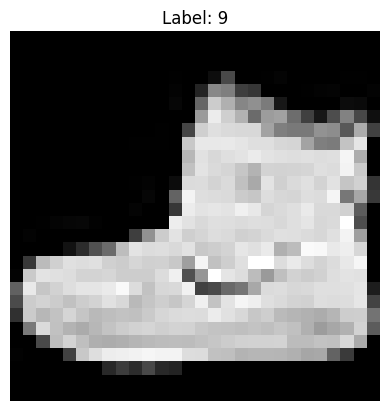

In [9]:
import keras
import numpy as np
import matplotlib.pyplot as plt

# Load dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.fashion_mnist.load_data()

# Data Checking
print('Length of training dataset:', len(X_train))
print('Length of test dataset:', len(X_test))
print('Unique value:', len(np.unique(y_train)))

plt.imshow(X_train[0], cmap="gray")
plt.title(f"Label: {y_train[0]}")
plt.axis("off")
plt.show()


Epoch 1/20


c:\Users\Fauzan Amrulloh\AppData\Local\Programs\Python\Python313\Lib\site-packages\keras\src\layers\reshaping\flatten.py:37: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.7913 - loss: 0.5862 - val_accuracy: 0.8517 - val_loss: 0.4159
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8416 - loss: 0.4372 - val_accuracy: 0.8642 - val_loss: 0.3759
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8541 - loss: 0.3989 - val_accuracy: 0.8729 - val_loss: 0.3536
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8622 - loss: 0.3766 - val_accuracy: 0.8746 - val_loss: 0.3472
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8679 - loss: 0.3601 - val_accuracy: 0.8774 - val_loss: 0.3396
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8702 - loss: 0.3481 - val_accuracy: 0.8648 - val_loss: 0.3630
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8750 - loss: 0.3365 - val_accuracy: 0.8785 - val_loss: 0.3337
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - accuracy: 0.8776 - loss: 0.3289 - val_accurac

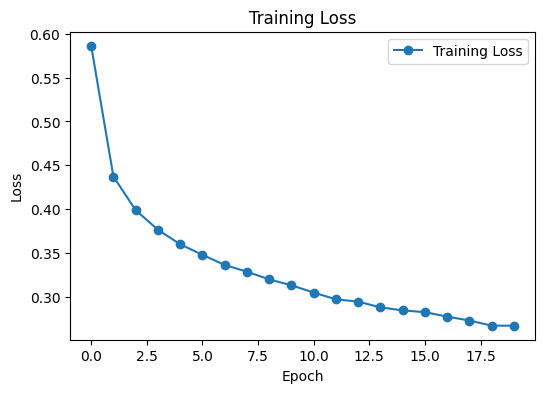

In [10]:
# Normalization 
X_train = X_train/255.0
X_test = X_test/255.0

# Modeling
model = keras.Sequential([
    keras.layers.Flatten(input_shape=(28,28)),
    keras.layers.Dense(300, activation='relu'),
    keras.layers.Dropout(0.3),
    keras.layers.Dense(100, activation='relu'),
    keras.layers.Dropout(0.2),
    keras.layers.Dense(10, activation='softmax'),
])

model.compile(
    optimizer='adam', 
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy'],
    )

# Training model
history = model.fit(X_train, y_train, epochs=20, validation_split=0.2)

# Evaluate
loss, accuracy = model.evaluate(X_test, y_test)
print(f'accuracy: {accuracy}')

# Predict image
predict = model.predict(X_test[:1])

print('prediction:', predict.argmax())
print('Actual:', y_test[0])

# Visualize
plt.figure(figsize=(6,4))
plt.plot(history.history["loss"], marker="o", label="Training Loss")
plt.title("Training Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()